# Breakout Room #4 — La curva Qini: ¿el modelo ordena de verdad?

**Objetivo:** construir la curva Qini y la tabla de deciles para comparar dos formas de
ordenar a los 14,000 clientes del experimento — por **riesgo/churn** y por **uplift
(T-learner)** — y ver cuál de las dos sirve de verdad para decidir a quién contactar.

Esta vez separamos los datos en dos partes: **entrenamiento** (para que los modelos
aprendan) y **prueba** (para evaluarlos con datos que nunca vieron — la misma idea de "las
dos ventanas" del Breakout 2, pero aplicada a modelos en vez de a fechas).

Donde dice **`# TODO`** hay algo para que ustedes completen.


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/data/uplift_experiment.csv")
FEATURES = ["recency_days", "frequency", "monetary", "email_open_rate"]

train, test = train_test_split(df, test_size=0.30, random_state=42, stratify=df["treatment_group"])
print(f"Entrenamiento: {len(train):,} clientes · Prueba: {len(test):,} clientes (el modelo nunca los ve)")


Entrenamiento: 9,800 clientes · Prueba: 4,200 clientes (el modelo nunca los ve)


## Paso 1 — entrenen los dos modelos (solo con datos de ENTRENAMIENTO)

- **`modelo_riesgo`**: un modelo de churn normal y corriente. No sabe nada de tratamiento/control
  — mezcla a todos los clientes de entrenamiento y aprende a predecir quién NO va a responder
  (`churned = 1 - responded_90d`). Así funcionaría un modelo de churn tradicional, el mismo tipo
  que construyeron en el Breakout 2.
- **`modelo_tratado`** y **`modelo_control`**: el T-learner de siempre (Breakout 3), entrenado
  solo con las filas de entrenamiento.


In [3]:
from sklearn.linear_model import LogisticRegression

# --- Modelo de riesgo (churn tradicional) ---
train["churned"] = 1 - train["responded_90d"]

X_riesgo = train[FEATURES]
y_riesgo = train["churned"]

modelo_riesgo = LogisticRegression().fit(X_riesgo, y_riesgo)

# --- Modelo tratado (T-Learner) ---
train_tratados = train[train["treatment_group"] == "treatment"]
X_tratados = train_tratados[FEATURES]
y_tratados = train_tratados["responded_90d"]

modelo_tratado = LogisticRegression().fit(X_tratados, y_tratados)

# --- Modelo control (T-Learner) ---
train_control = train[train["treatment_group"] == "control"]
X_control = train_control[FEATURES]
y_control = train_control["responded_90d"]

modelo_control = LogisticRegression().fit(X_control, y_control)

print("Modelos entrenados: riesgo, tratado y control.")


Modelos entrenados: riesgo, tratado y control.


## Paso 2 — puntúen el conjunto de PRUEBA (el que ningún modelo vio)

Igual que en el Breakout 3: le preguntan a los modelos sobre todos los clientes de prueba,
tratados y de control por igual.


In [10]:
test = test.copy()
X_test = test[FEATURES]

# TODO: calculen las tres probabilidades sobre el conjunto de prueba



# 1️⃣ Probabilidad de churn (modelo_riesgo)
test["prob_churn"] = modelo_riesgo.predict_proba(X_test)[:, 1]

# 2️⃣ Probabilidad de compra si tratado (modelo_tratado)
test["prob_tratado"] = modelo_tratado.predict_proba(X_test)[:, 1]

# 3️⃣ Probabilidad de compra si control (modelo_control)
test["prob_control"] = modelo_control.predict_proba(X_test)[:, 1]

# 4️⃣ Uplift estimado
test["uplift_estimado"] = test["prob_tratado"] - test["prob_control"]

# Vista rápida
print(test[["customer_id","prob_churn","prob_tratado","prob_control","uplift_estimado"]].head())



       customer_id  prob_churn  prob_tratado  prob_control  uplift_estimado
1514          1515    0.904556      0.109271      0.071850         0.037421
11250        11251    0.270724      0.826063      0.645906         0.180157
13938        13939    0.601709      0.465817      0.326372         0.139445
7824          7825    0.747900      0.358274      0.160365         0.197909
8723          8724    0.732951      0.362741      0.178745         0.183995


## Paso 3 — la curva Qini

Para cada corte N (del 2.5% al 100% de la base de prueba, ordenada de "mejor" a "peor" según el
modelo), midan:

```
ganancia(N) = (tasa de respuesta de los tratados en el top N  −  tasa de respuesta del control en el top N)  ×  N
```

Esa es la curva — compara contra la diagonal del azar. El **coeficiente Qini** es, sencillamente,
el área entre la curva del modelo y la diagonal del azar: entre más área (más arriba de la
diagonal), mejor ordena el modelo.


In [11]:
def curva_qini(test_df, score_col, steps=40):
    orden = test_df.sort_values(score_col, ascending=False).reset_index(drop=True)
    es_tratado = (orden["treatment_group"] == "treatment").values
    respondio = orden["responded_90d"].values

    acumulado_tratados = np.cumsum(np.where(es_tratado, respondio, 0))
    acumulado_control = np.cumsum(np.where(~es_tratado, respondio, 0))
    n_tratados_acum = np.cumsum(es_tratado)
    n_control_acum = np.cumsum(~es_tratado)

    n = len(orden)
    xs, ys = [0.0], [0.0]
    for i in np.linspace(1, n, steps).astype(int):
        nt, nc = n_tratados_acum[i - 1], n_control_acum[i - 1]
        tasa_t = acumulado_tratados[i - 1] / nt if nt > 0 else 0
        tasa_c = acumulado_control[i - 1] / nc if nc > 0 else 0
        xs.append(i / n)
        ys.append((tasa_t - tasa_c) * n)
    return np.array(xs), np.array(ys)


def coeficiente_qini(xs, ys):
    area_modelo = np.trapezoid(ys, xs)
    area_azar = np.trapezoid(np.linspace(0, ys[-1], len(xs)), xs)
    return (area_modelo - area_azar) / len(test)


xs_uplift, ys_uplift = curva_qini(test, "uplift_estimado")
xs_riesgo, ys_riesgo = curva_qini(test, "prob_churn")

qini_uplift = coeficiente_qini(xs_uplift, ys_uplift)
qini_riesgo = coeficiente_qini(xs_riesgo, ys_riesgo)

print(f"Coeficiente Qini · modelo de uplift (T-learner): {qini_uplift:+.3f}")
print(f"Coeficiente Qini · modelo de riesgo (churn):      {qini_riesgo:+.3f}")


Coeficiente Qini · modelo de uplift (T-learner): +0.222
Coeficiente Qini · modelo de riesgo (churn):      +0.006


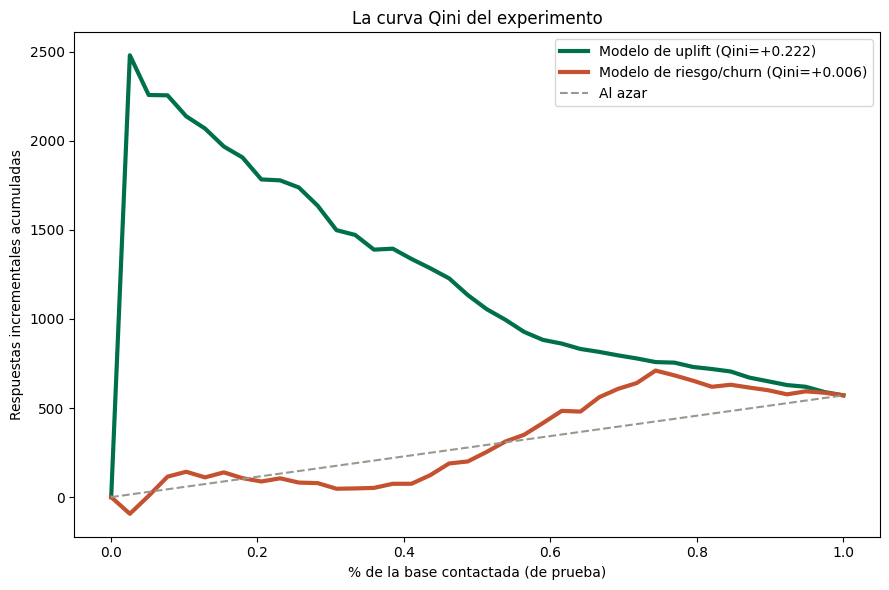

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs_uplift, ys_uplift, color="#00704A", linewidth=3, label=f"Modelo de uplift (Qini={qini_uplift:+.3f})")
ax.plot(xs_riesgo, ys_riesgo, color="#C4512F", linewidth=3, label=f"Modelo de riesgo/churn (Qini={qini_riesgo:+.3f})")
ax.plot([0, 1], [0, ys_uplift[-1]], color="#9A988E", linestyle="--", label="Al azar")
ax.set_xlabel("% de la base contactada (de prueba)")
ax.set_ylabel("Respuestas incrementales acumuladas")
ax.set_title("La curva Qini del experimento")
ax.legend()
plt.tight_layout()
plt.savefig("curva_qini.png", dpi=150)
plt.show()


## Paso 4 — la tabla de deciles: ¿el modelo ordena de verdad?

Dividan el conjunto de prueba en 10 deciles según `uplift_estimado` (decil 1 = uplift más alto
predicho). Para cada decil, comparen el uplift PREDICHO promedio contra el uplift REAL (tasa de
respuesta de tratados menos tasa de respuesta de control, DENTRO de ese decil).


In [13]:
test["decil"] = pd.qcut(test["uplift_estimado"], 10, labels=False, duplicates="drop")
test["decil"] = 9 - test["decil"]  # decil 1 = el de mayor uplift predicho

filas = []
for d in range(10):
    grp = test[test["decil"] == d]
    pred = grp["uplift_estimado"].mean()
    real_t = grp.loc[grp["treatment_group"] == "treatment", "responded_90d"].mean()
    real_c = grp.loc[grp["treatment_group"] == "control", "responded_90d"].mean()
    filas.append({"decil": d + 1, "uplift_predicho": round(pred, 3), "uplift_real": round(real_t - real_c, 3), "n": len(grp)})

tabla_deciles = pd.DataFrame(filas)
tabla_deciles


,decil,uplift_predicho,uplift_real,n
0,1,0.394,0.505,420
1,2,0.286,0.347,420
2,3,0.216,0.241,420
3,4,0.168,0.199,420
4,5,0.129,0.051,420
5,6,0.099,-0.059,420
6,7,0.074,0.078,420
7,8,0.053,0.054,420
8,9,0.031,0.022,420
9,10,-0.009,-0.022,420


## Para la Clase

1. ¿El coeficiente Qini del modelo de riesgo/churn es mayor, menor o parecido al del modelo de
   uplift? ¿Qué dice eso sobre usar un modelo de churn para decidir a quién contactar?

Modelo de riesgo/churn: Qini ≈ +0.006
Modelo de uplift: Qini ≈ +0.222

El coeficiente del modelo de uplift es mucho mayor.
Esto demuestra que el modelo de churn no sirve para decidir a quién contactar, porque solo predice quién tiene baja probabilidad de compra, pero no distingue si el contacto cambia algo.
El uplift, en cambio, mide el efecto causal del contacto y prioriza a los Persuadables, generando verdadero valor incremental.

2. Miren la tabla de deciles: ¿hay algún decil donde lo predicho y lo real se alejan mucho?
   Con ~420 clientes por decil, ¿qué tan confiables son esos números?


Con ~420 clientes por decil, los promedios son razonablemente confiables para ver tendencias generales, pero no para decisiones individuales.

A nivel decil, el error estándar es pequeño.

A nivel cliente, la varianza es alta.
Por eso se evalúan políticas por grupos (deciles o percentiles), no por individuos.


3. Si tuvieran que explicarle a alguien de negocio qué es el coeficiente Qini en una frase,
   ¿qué dirían?

   cuanto más alto el Qini, más rentable y eficiente es tu targeting.
